# ch280 — Correlation

*(Extends covariance from ch273; connects to dot product from ch131 — Dot Product Intuition)*

## 1. From Covariance to Correlation

Covariance measures joint variation but is scale-dependent. Dividing by the product of standard deviations normalizes it to the interval [−1, 1]:

$$r = \frac{\text{Cov}(X,Y)}{\sigma_X \sigma_Y} = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i-\bar{x})^2 \cdot \sum(y_i-\bar{y})^2}}$$

This is Pearson's correlation coefficient. Geometrically, it is the cosine of the angle between the **mean-centered** vectors $\mathbf{x} - \bar{x}$ and $\mathbf{y} - \bar{y}$ — a direct application of the dot product interpretation from ch131.

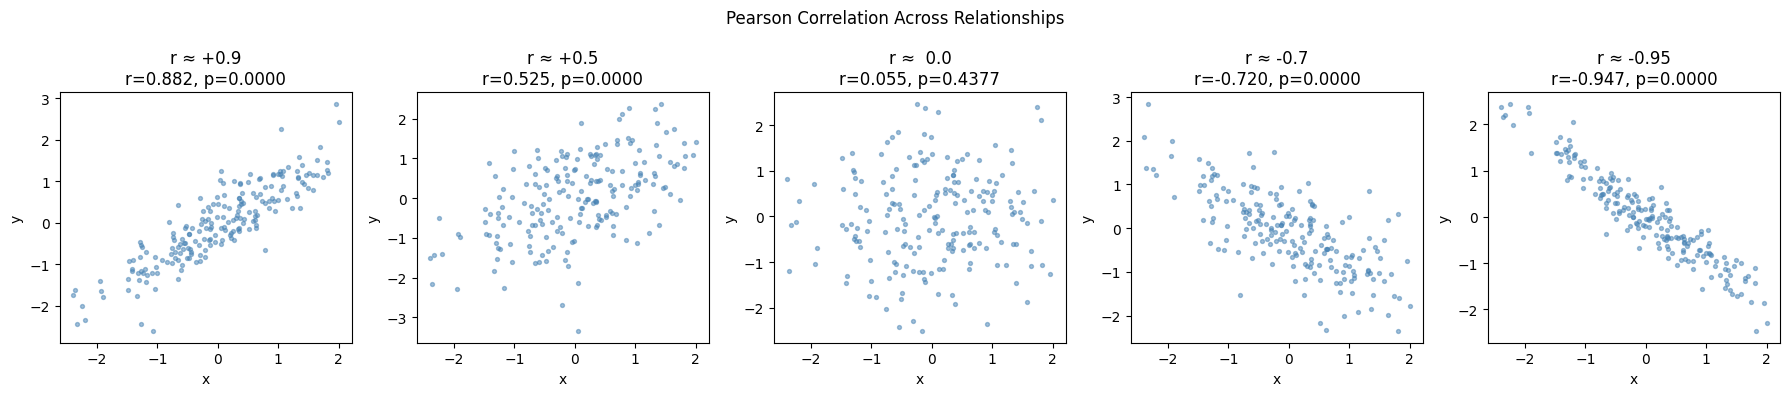

r ≈ +0.9: manual=0.8823, scipy=0.8823, match=True
r ≈ +0.5: manual=0.5250, scipy=0.5250, match=True


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(0)

def pearson_r(x: np.ndarray, y: np.ndarray) -> float:
    """Pearson correlation coefficient."""
    xc = x - x.mean()
    yc = y - y.mean()
    return np.dot(xc, yc) / (np.linalg.norm(xc) * np.linalg.norm(yc))

def pearson_r_with_pvalue(
    x: np.ndarray, y: np.ndarray
) -> tuple[float, float]:
    """Returns (r, p-value) for H0: r=0."""
    r = pearson_r(x, y)
    n = len(x)
    # t-transform
    t = r * np.sqrt(n - 2) / np.sqrt(1 - r**2 + 1e-15)
    p = 2 * stats.t.sf(abs(t), df=n-2)
    return r, p

n = 200
x = rng.normal(0, 1, n)

correlations = {
    'r ≈ +0.9': 0.9*x + np.sqrt(1-0.9**2)*rng.normal(0,1,n),
    'r ≈ +0.5': 0.5*x + np.sqrt(1-0.5**2)*rng.normal(0,1,n),
    'r ≈  0.0': rng.normal(0,1,n),
    'r ≈ -0.7': -0.7*x + np.sqrt(1-0.7**2)*rng.normal(0,1,n),
    'r ≈ -0.95': -0.95*x + np.sqrt(1-0.95**2)*rng.normal(0,1,n),
}

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, (label, y) in zip(axes, correlations.items()):
    r, p = pearson_r_with_pvalue(x, y)
    ax.scatter(x, y, s=8, alpha=0.5, color='steelblue')
    ax.set_title(f'{label}\nr={r:.3f}, p={p:.4f}')
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle('Pearson Correlation Across Relationships', fontsize=12)
plt.tight_layout()
plt.show()

# Validate against scipy
for label, y in list(correlations.items())[:2]:
    r_manual, _ = pearson_r_with_pvalue(x, y)
    r_scipy, _  = stats.pearsonr(x, y)
    print(f"{label}: manual={r_manual:.4f}, scipy={r_scipy:.4f}, match={np.isclose(r_manual, r_scipy)}")

## 2. Correlation ≠ Causation; Correlation ≠ Linear Relationship

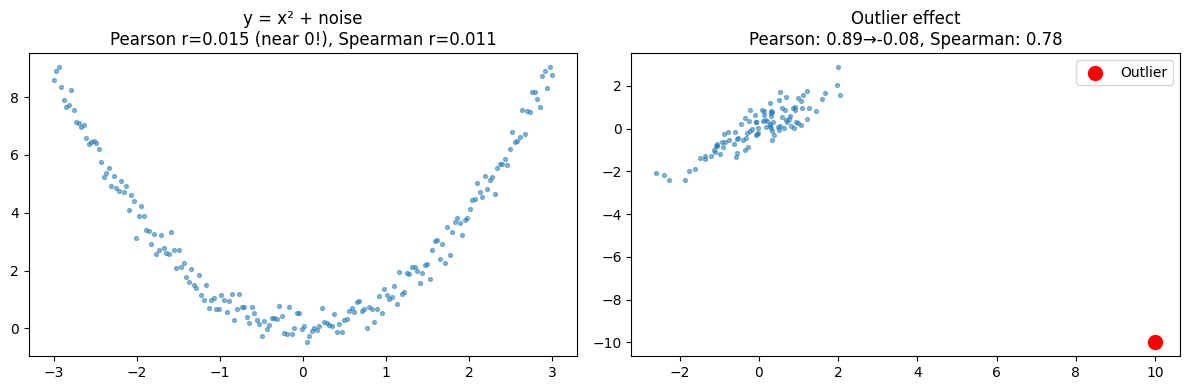

In [2]:
# Anscombe-style: high correlation with nonlinear relationship
x_nl = np.linspace(-3, 3, 200)
y_nl = x_nl**2 + rng.normal(0, 0.3, 200)  # perfect quadratic, r ≈ 0!

r_nl, _ = pearson_r_with_pvalue(x_nl, y_nl)

# Spearman rank correlation (robust to nonlinearity)
def spearman_r(x, y):
    """Spearman rank correlation."""
    def rank(arr):
        order = np.argsort(arr)
        ranks = np.empty_like(order, dtype=float)
        ranks[order] = np.arange(1, len(arr)+1)
        return ranks
    return pearson_r(rank(x), rank(y))

r_sp = spearman_r(x_nl, y_nl)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(x_nl, y_nl, s=8, alpha=0.5)
ax1.set_title(f'y = x² + noise\nPearson r={r_nl:.3f} (near 0!), Spearman r={r_sp:.3f}')

# Outlier sensitivity
x_out = rng.normal(0, 1, 100)
y_out = x_out + rng.normal(0, 0.5, 100)
x_with = np.append(x_out, 10)  # one extreme outlier
y_with = np.append(y_out, -10)

r_clean  = pearson_r(x_out, y_out)
r_dirty  = pearson_r(x_with, y_with)
rs_dirty = spearman_r(x_with, y_with)

ax2.scatter(x_with, y_with, s=8, alpha=0.5)
ax2.scatter([10], [-10], color='red', s=100, zorder=5, label='Outlier')
ax2.set_title(f'Outlier effect\nPearson: {r_clean:.2f}→{r_dirty:.2f}, Spearman: {rs_dirty:.2f}')
ax2.legend()

plt.tight_layout()
plt.show()

## 3. Correlation Matrix

Match with np.corrcoef: True


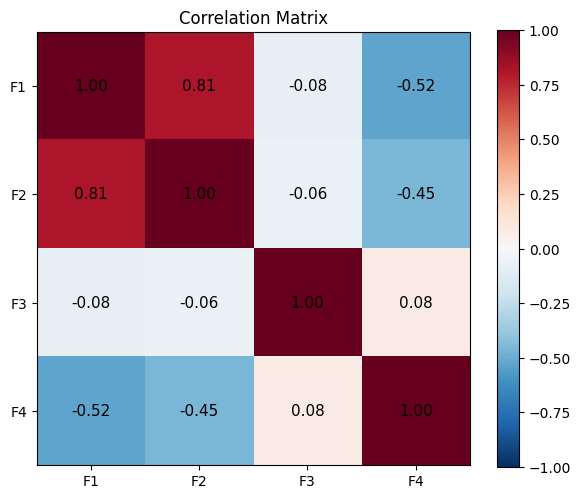

In [3]:
# Correlation matrix from scratch
def correlation_matrix(X: np.ndarray) -> np.ndarray:
    """X: shape (n_samples, n_features)"""
    X_centered = X - X.mean(axis=0)
    norms = np.linalg.norm(X_centered, axis=0)
    X_normalized = X_centered / norms  # unit vectors
    return X_normalized.T @ X_normalized  # dot products = cosines

n = 300
f1 = rng.normal(0, 1, n)
f2 = 0.8 * f1 + 0.6 * rng.normal(0, 1, n)
f3 = rng.normal(0, 1, n)
f4 = -0.5 * f1 + 0.866 * rng.normal(0, 1, n)
X  = np.column_stack([f1, f2, f3, f4])

C_manual = correlation_matrix(X)
C_numpy  = np.corrcoef(X.T)
print("Match with np.corrcoef:", np.allclose(C_manual, C_numpy, atol=1e-10))

fig, ax = plt.subplots(figsize=(6, 5))
labels = ['F1', 'F2', 'F3', 'F4']
im = ax.imshow(C_manual, cmap='RdBu_r', vmin=-1, vmax=1)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{C_manual[i,j]:.2f}', ha='center', va='center', fontsize=11)
ax.set_xticks(range(4)); ax.set_xticklabels(labels)
ax.set_yticks(range(4)); ax.set_yticklabels(labels)
plt.colorbar(im, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 4. What Comes Next

Correlation quantifies the linear relationship between two variables. **ch281 — Regression** builds on correlation to produce a predictive model: given $x$, estimate $y$. The correlation coefficient $r$ and the regression slope $\beta$ are related by $\beta = r \cdot (\sigma_y / \sigma_x)$.

The correlation matrix computed here will be decomposed by PCA in **ch292 — Dimensionality Reduction** to find the directions of maximum variance.